# Scanner–human agreement GLM — independent fits per criterion

Logistic regression assessing agreement between automated **scanner grades**
and **human grades** after binarizing both, per `analysis/glm_plan.md`.
Data access follows the same config-driven pattern as `scanner_glm.ipynb`:
a YAML config under `analysis/configs/` lists
`(target_scanner, split, scan_ids, validation_files)` blocks; every block is
loaded and merged with its human validation grades.

Each row of the model frame is one **grading observation**: a
(transcript, criterion, scanner_model) cell with both a scanner grade and a
human grade, binarized with the config threshold.

## Model

The four criteria (`target_scanner` blocks) are **fully independent runs** —
different scanner prompts, different transcript samples, different human
validation sets — so each criterion gets its **own independent fit** of the
plan's model rather than entering a pooled model as a factor:

```
human_grade ~ scanner_grade_centered * scanner_model * benchmark    (per criterion)
```

- Binary outcome `human_grade`, logit link.
- `scanner_grade_centered = scanner_grade − 0.5` (so 0 → −0.5, 1 → +0.5).
- **Sum/effect coding** for `scanner_model` and `benchmark`, so each fit's
  intercept is that criterion's grand-average log-odds of `human_grade = 1`
  and every factor coefficient is a deviation from that average.
- Factor levels are determined **within** each criterion. Criteria observed
  on a single benchmark (currently `guessing` and `tool_failure`, which are
  core_bench-only) automatically lose the benchmark columns — their model
  reduces to `scanner_grade_centered * scanner_model`.

Nothing is shared between fits: no pooling, no common intercept, no shared
priors beyond using the same (weakly informative) prior settings.

A nested ladder up to the plan's full three-way model is fit and compared
with LOO-CV for every criterion, but the **primary model** used for all
reported quantities is `m2_scanner_assoc`:

```
human_grade ~ scanner_grade_centered + scanner_model + benchmark    (per criterion)
```

The LOO comparison showed the agreement-interaction blocks
(`sgc:scanner_model`, `sgc:benchmark`, and the `scanner_model × benchmark`
structure) do not improve out-of-sample prediction in any criterion, so each
criterion gets a single scanner–human association coefficient on top of
main-effect baselines. Set `PRIMARY_MODEL` in the design cell to change
this (e.g. back to `"m4_full"` for the full structure).

- The fit is Bayesian. The coefficient table reports posterior mean / sd and
  a two-sided directional posterior probability as analogs of the requested
  estimate / SE / p-value (frequentist `statsmodels` is not installed).
- Intervals are 95% equal-tailed posterior credible intervals.
- The priors mildly regularize cells with perfect separation (small
  scanner_model × benchmark cells where the scanner is always right or
  always wrong), which a maximum-likelihood fit would not handle. This
  matters more here than in a pooled fit: the per-criterion samples are
  small (90–290 observations).

## Outputs (each per criterion)

1. Model comparison: a nested ladder scored with LOO-CV, to justify the
   parameter blocks in the primary model.
2. Coefficient table (effect-coded, log-odds scale + odds ratios).
3. Marginal predicted probabilities `P(human=1 | scanner grade, model, benchmark)`.
4. Agreement summary per scanner_model × benchmark cell:
   `delta`, PPV-like, NPV-like.
5. Posterior predictive check on per-cell human-positive rates.

The headline results are (3) and (4): effect-coded coefficients are
deviations on the log-odds scale, so marginal probabilities and `delta` are
the quantities to communicate.

A closing **missed-issues section** flips the conditioning — a mirror GLM
of `scanner_grade ~ human_grade_centered * scanner_model` per criterion —
to estimate sensitivity, miss rate, and Youden's J, plus a
detection-by-severity breakdown and a shared-miss overlap diagnostic.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/jeffm/projects/scanner_evaluation")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import jax
import jax.numpy as jnp
import arviz as az
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from analysis.scan_utils import load_scan_results, load_validations
from analysis.analysis_utils import (
    BENCHMARK_ALIASES,
    shorten_model,
)

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 24)
numpyro.set_host_device_count(2)

## Config

Same config as `scanner_glm.ipynb`. Swap `CONFIG_PATH` to change scanners,
splits, scan_ids, validation files, the binarization threshold, or MCMC
settings. Outputs are saved under `<results_subdir>/agreement/` to keep them
separate from the violation-rate GLM's artifacts.

In [2]:
import yaml

CONFIG_PATH = PROJECT_ROOT / "analysis" / "configs" / "glm_test_all.yaml"

with open(CONFIG_PATH) as f:
    _cfg = yaml.safe_load(f)

SCANNER_SPECS: list[dict] = list(_cfg.get("scanners") or [])
if not SCANNER_SPECS:
    raise ValueError("Config must list at least one entry under `scanners`.")

VIOLATION_THRESHOLD: int = int(_cfg.get("violation_threshold", 2))
_bench = _cfg.get("benchmarks")
BENCHMARKS: list[str] | None = list(_bench) if _bench else None
MCMC_CFG: dict = dict(_cfg.get("mcmc") or {})
MCMC_CFG.setdefault("num_warmup", 1000)
MCMC_CFG.setdefault("num_samples", 1000)
MCMC_CFG.setdefault("num_chains", 2)
MCMC_CFG.setdefault("seed", 0)

_results_subdir = _cfg.get("results_subdir")
RESULTS_DIR: Path | None = (
    PROJECT_ROOT / "analysis" / "results" / _results_subdir
    if _results_subdir
    else None
)
if RESULTS_DIR is not None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"CONFIG              = {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"VIOLATION_THRESHOLD = {VIOLATION_THRESHOLD}")
print(f"BENCHMARKS          = {BENCHMARKS if BENCHMARKS else '(no filter)'}")
print(f"MCMC                = {MCMC_CFG}")
print(f"RESULTS_DIR         = {RESULTS_DIR if RESULTS_DIR else '(not saving outputs)'}")
print(f"SCANNER_SPECS ({len(SCANNER_SPECS)}):")
for s in SCANNER_SPECS:
    print(f"  - {s['target_scanner']}/{s['split']}  scan_ids={s.get('scan_ids')}  val={s.get('validation_files')}")

CONFIG              = analysis/configs/glm_test_all.yaml
VIOLATION_THRESHOLD = 2
BENCHMARKS          = (no filter)
MCMC                = {'num_warmup': 1000, 'num_samples': 1000, 'num_chains': 2, 'seed': 0}
RESULTS_DIR         = /home/jeffm/projects/scanner_evaluation/analysis/results/glm/glm_test_all
SCANNER_SPECS (4):
  - ground_truth_access/test  scan_ids=[]  val=['post_validation_sample_MH6UxNTcbmXqXVqJnmmb7G_DS.csv', 'post_validation_sample_2WQYwt7yGUjXWvRxbhcMz8_AH.csv']
  - tool_failure/test  scan_ids=['SUmMAP2H2qEkwkBj8ts8QH', 'JtPRTDpECuV9Qy2DUXWxNz']  val=['post_validation_sample_SUmMAP2H2qEkwkBj8ts8QH_DS.csv']
  - answer_format/test  scan_ids=['gRzXcrEozh3X2z2SLzeHeM', 'BtPArb3ujCx9Zmw2kgNjp7']  val=['post_validation_sample_gRzXcrEozh3X2z2SLzeHeM.csv']
  - guessing/test  scan_ids=['Vnb6GhThvWxeBFz427kMRb', '6y5opBB3gB7FtBYFi38WdQ']  val=['post_validation_sample_Vnb6GhThvWxeBFz427kMRb_AH.csv']


## Build the combined frame

Per block: load every requested `scan_id=*` parquet, attach metadata, and
merge the per-block validation CSV(s). Concatenate blocks into one frame.
Same loader as `scanner_glm.ipynb` / `scanner_combined_results.ipynb`.

In [3]:
def _load_validation_long(
    validation_dir: Path,
    requested_files: list[str] | None,
    target_scanner: str,
) -> pd.DataFrame:
    if not validation_dir.exists() or not any(validation_dir.glob("*.csv")):
        print(f"  [{target_scanner}] no validation directory at {validation_dir}")
        return pd.DataFrame(columns=["transcript_id", "validation_grade"])
    wide = load_validations(validation_dir, prefix="")
    grade_cols = [c for c in wide.columns if c != "transcript_id"]
    if requested_files is None:
        selected = grade_cols
    else:
        target_stems = [Path(f).stem for f in requested_files]
        missing = [s for s in target_stems if s not in grade_cols]
        if missing:
            raise FileNotFoundError(
                f"validation_files entries not found in {validation_dir}: {missing}. "
                f"Available: {grade_cols}"
            )
        selected = target_stems
    long = (
        wide[["transcript_id"] + selected]
        .melt(id_vars="transcript_id", var_name="source_file", value_name="validation_grade")
    )
    long["validation_grade"] = pd.to_numeric(long["validation_grade"], errors="coerce")
    long = long.dropna(subset=["validation_grade"])
    return (
        long.drop_duplicates("transcript_id", keep="first")
        [["transcript_id", "validation_grade"]]
        .reset_index(drop=True)
    )


def _load_block(spec: dict) -> pd.DataFrame:
    target_scanner = spec["target_scanner"]
    split = spec["split"]
    requested_scan_ids = list(spec.get("scan_ids") or [])
    requested_scanner_key = spec.get("scanner_key")
    requested_validation = spec.get("validation_files")

    base = PROJECT_ROOT / "evals" / "scans" / target_scanner / split
    raw = load_scan_results(base / "scan-results").copy()
    raw["target_scanner"] = target_scanner
    raw["split"] = split
    raw["scan_id"] = raw["scanner_source"].str.removeprefix("scan_id=")
    raw["scanner_model"] = raw["scanner_model"].map(shorten_model)
    raw["eval_generation_model"] = raw["transcript_model"].map(shorten_model)
    raw["benchmark"] = raw["transcript_task_set"].map(
        lambda b: BENCHMARK_ALIASES.get(b, b)
    )
    raw["scanner_label"] = (
        raw["scanner_model"].fillna("(no model)").astype(str) + " · " + raw["scan_id"].str[:6]
    )

    present_keys = sorted(raw["scanner_key"].dropna().unique().tolist())
    if requested_scanner_key is not None:
        resolved_key = requested_scanner_key
    elif len(present_keys) == 1:
        resolved_key = present_keys[0]
    else:
        raise RuntimeError(
            f"[{target_scanner}] multiple scanner_keys present ({present_keys}); set `scanner_key`."
        )
    raw = raw[raw["scanner_key"] == resolved_key].copy()

    if requested_scan_ids:
        raw = raw[raw["scan_id"].isin(requested_scan_ids)].copy()

    validation = _load_validation_long(base / "validation", requested_validation, target_scanner)
    if not validation.empty:
        raw = raw.merge(validation, on="transcript_id", how="left")
    else:
        raw["validation_grade"] = np.nan

    print(
        f"  [{target_scanner}/{split}] {len(raw):,} rows · "
        f"{raw['scan_id'].nunique()} scan_id(s) · "
        f"{int(raw['validation_grade'].notna().sum()):,} with human grade"
    )
    return raw


KEEP_COLS = [
    "target_scanner", "split", "scanner_key", "scan_id", "scanner_label",
    "scanner_model", "transcript_id", "value_num", "benchmark",
    "eval_generation_model", "validation_grade",
]
combined = pd.concat(
    [_load_block(spec).reindex(columns=KEEP_COLS) for spec in SCANNER_SPECS],
    ignore_index=True,
)
combined = combined.rename(columns={"value_num": "scanner_grade"})

print()
print(f"Combined: {len(combined):,} rows · {combined['transcript_id'].nunique():,} transcripts")
print(f"  benchmarks       : {sorted(combined['benchmark'].dropna().unique())}")
print(f"  target_scanners  : {sorted(combined['target_scanner'].unique())}")
print(f"  with validation  : {int(combined['validation_grade'].notna().sum()):,}")
display(combined.head(6))

  [ground_truth_access/test] 2,162 rows · 6 scan_id(s) · 666 with human grade
  [tool_failure/test] 1,790 rows · 2 scan_id(s) · 284 with human grade
  [answer_format/test] 3,582 rows · 2 scan_id(s) · 476 with human grade
  [guessing/test] 2,304 rows · 2 scan_id(s) · 312 with human grade

Combined: 9,838 rows · 1,977 transcripts
  benchmarks       : ['core_bench', 'cvebench', 'gpqa_diamond', 'hle', 'kernelbench', 'swe_bench', 'tau2_airline', 'tau2_retail']
  target_scanners  : ['answer_format', 'ground_truth_access', 'guessing', 'tool_failure']
  with validation  : 1,738


,target_scanner,split,scanner_key,scan_id,scanner_label,scanner_model,transcript_id,scanner_grade,benchmark,eval_generation_model,validation_grade
0,ground_truth_access,test,ground_truth_access,2WQYwt7yGUjXWvRxbhcMz8,gpt-5.4 · 2WQYwt,gpt-5.4,23PuSLfTSGCbj2JgagmbaU,1.0,core_bench,sonnet-4.6,NaN
1,ground_truth_access,test,ground_truth_access,2WQYwt7yGUjXWvRxbhcMz8,gpt-5.4 · 2WQYwt,gpt-5.4,23j88DhU4jR85dpu2NZCCp,2.0,swe_bench,sonnet-4.6,NaN
2,ground_truth_access,test,ground_truth_access,2WQYwt7yGUjXWvRxbhcMz8,gpt-5.4 · 2WQYwt,gpt-5.4,26AxECRayt66dHuzdhEgSj,1.0,swe_bench,sonnet-4.6,NaN
3,ground_truth_access,test,ground_truth_access,2WQYwt7yGUjXWvRxbhcMz8,gpt-5.4 · 2WQYwt,gpt-5.4,292xz4pnzWBbR9wjmeJuhk,3.0,swe_bench,sonnet-4.6,NaN
4,ground_truth_access,test,ground_truth_access,2WQYwt7yGUjXWvRxbhcMz8,gpt-5.4 · 2WQYwt,gpt-5.4,2JZv5dGYVWizSLHVm25SXH,1.0,swe_bench,sonnet-4.6,NaN
5,ground_truth_access,test,ground_truth_access,2WQYwt7yGUjXWvRxbhcMz8,gpt-5.4 · 2WQYwt,gpt-5.4,2aJtq9kbPvTsad62YtbDFG,1.0,swe_bench,gpt-5.4,NaN


## Build the model frame

One row per **(transcript, criterion, scanner_model)** grading observation,
keeping only rows that have *both* a scanner grade and a human grade:

- If multiple scan_ids from the same scanner model scored the same
  (transcript, criterion) cell, take the **max** ordinal grade (one scanner
  judgment per cell, matching `scanner_glm.ipynb`). The human grade is
  constant within a cell.
- Binarize both grades with the config threshold:
  `grade_bin = 1{grade_ordinal >= VIOLATION_THRESHOLD}`.
- `scanner_grade_centered = scanner_grade − 0.5`.
- Apply the config benchmark filter.

The frame holds all criteria; every modelling step below operates on one
criterion's slice at a time.

In [4]:
rows = combined.dropna(subset=["scanner_grade", "validation_grade", "benchmark"]).copy()
rows = rows.rename(columns={"target_scanner": "criterion"})
if BENCHMARKS is not None:
    rows = rows[rows["benchmark"].isin(BENCHMARKS)].copy()

df = (
    rows.groupby(
        ["transcript_id", "criterion", "scanner_model", "benchmark"],
        as_index=False,
    )
    .agg(
        scanner_grade_ord=("scanner_grade", "max"),
        human_grade_ord=("validation_grade", "first"),
    )
)

df["scanner_grade"] = (df["scanner_grade_ord"] >= VIOLATION_THRESHOLD).astype(int)
df["human_grade"] = (df["human_grade_ord"] >= VIOLATION_THRESHOLD).astype(int)
df["scanner_grade_centered"] = df["scanner_grade"] - 0.5

CRITERIA = sorted(df["criterion"].unique())

print(f"Model frame: {len(df):,} grading observations")
print(f"  scanner_models : {sorted(df['scanner_model'].unique())}")
print(f"  benchmarks     : {sorted(df['benchmark'].unique())}")
print(f"  criteria       : {CRITERIA}")
print(f"  human_grade=1  : {df['human_grade'].mean():.3f}")
print(f"  scanner_grade=1: {df['scanner_grade'].mean():.3f}")

print("\nObservations per criterion × benchmark:")
display(pd.crosstab(df["criterion"], df["benchmark"]))

print("\nObserved P(human=1) and n, per criterion × scanner_model × benchmark × scanner_grade:")
display(
    df.groupby(["criterion", "scanner_model", "benchmark", "scanner_grade"])["human_grade"]
    .agg(n="size", obs_rate="mean")
    .round(3)
)

Model frame: 1,736 grading observations
  scanner_models : ['gpt-5.4', 'sonnet-4.6']
  benchmarks     : ['core_bench', 'cvebench', 'gpqa_diamond', 'hle', 'kernelbench', 'swe_bench', 'tau2_retail']
  criteria       : ['answer_format', 'ground_truth_access', 'guessing', 'tool_failure']
  human_grade=1  : 0.194
  scanner_grade=1: 0.291

Observations per criterion × benchmark:


benchmark,core_bench,cvebench,gpqa_diamond,hle,kernelbench,swe_bench,tau2_retail
criterion,,,,,,,
answer_format,74,58,50,99,78,62,54
ground_truth_access,146,70,0,0,50,200,200
guessing,100,58,53,100,0,0,0
tool_failure,74,52,0,0,58,100,0



Observed P(human=1) and n, per criterion × scanner_model × benchmark × scanner_grade:


n  obs_rate
criterion     scanner_model benchmark    scanner_grade              
answer_format gpt-5.4       core_bench   0              25     0.240
                                         1              12     0.583
                            cvebench     0              25     0.000
                                         1               4     1.000
                            gpqa_diamond 0              25     0.000
...                                                     ..       ...
tool_failure  sonnet-4.6    cvebench     0              26     0.000
                            kernelbench  0              28     0.143
                                         1               1     1.000
                            swe_bench    0              49     0.082
                                         1               1     1.000

[75 rows x 2 columns]

## Design matrices — effect coding + nested model ladder

Sum-to-zero (effect) coding for `scanner_model` and `benchmark`: each factor
with *k* levels contributes *k−1* columns; the (alphabetically) last level is
coded −1 in every column, so each coefficient is that level's deviation from
the grand mean and the last level's deviation is minus the sum of the others.
Interaction columns are elementwise products. Factor levels are computed
**within each criterion**, so a single-level factor (e.g. `benchmark` for the
core_bench-only criteria) contributes no columns and all terms involving it
vanish.

`build_design(frame, terms, levels)` assembles any model from a list of
terms, which defines a **nested ladder** fit per criterion:

| model | adds | question it answers |
|---|---|---|
| `m0_intercept` | intercept only | baseline |
| `m1_factors` | `scanner_model + benchmark` | do human-positive rates differ by factor? |
| `m2_scanner_assoc` *(primary)* | `+ scanner_grade_centered` | do scanner grades track human grades at all? |
| `m3_varying_assoc` | `+ sgc:scanner_model + sgc:benchmark` | does agreement vary by scanner / benchmark? |
| `m4_full` | `+ scanner_model:benchmark + sgc:scanner_model:benchmark` | the plan's full three-way structure |

For single-benchmark criteria some rungs collapse into the one below
(identical design columns); those duplicates are skipped. The primary model
is `PRIMARY_MODEL` (falling back to the deepest rung fit if a criterion's
ladder doesn't include it).

In [5]:
SGC = "scanner_grade_centered"


def _sum_code(series: pd.Series, levels: list[str], name: str) -> dict[str, np.ndarray]:
    # Sum-to-zero coding: one column per non-last level; the last level is
    # coded -1 everywhere, so effects sum to zero across levels. A
    # single-level factor contributes no columns.
    arr = series.to_numpy()
    out: dict[str, np.ndarray] = {}
    for lev in levels[:-1]:
        out[f"{name}[S.{lev}]"] = np.where(
            arr == lev, 1.0, np.where(arr == levels[-1], -1.0, 0.0)
        )
    return out


def build_design(
    frame: pd.DataFrame,
    terms: list[tuple[str, ...]],
    levels: dict[str, list[str]],
) -> pd.DataFrame:
    n = len(frame)
    cols: dict[str, np.ndarray] = {"Intercept": np.ones(n)}
    for term in terms:
        pieces: list[tuple[str, np.ndarray]] = [("", np.ones(n))]
        for var in term:
            if var not in levels:
                # not an effect-coded factor -> numeric covariate
                vals = frame[var].to_numpy(dtype=float)
                pieces = [
                    (f"{nm}:{var}" if nm else var, pv * vals) for nm, pv in pieces
                ]
            else:
                fcols = _sum_code(frame[var], levels[var], var)
                pieces = [
                    (f"{nm}:{fn}" if nm else fn, pv * fv)
                    for nm, pv in pieces
                    for fn, fv in fcols.items()
                ]
        for nm, vals in pieces:
            cols[nm] = vals
    return pd.DataFrame(cols, index=frame.index)


_t_factors = [("scanner_model",), ("benchmark",)]
_t_assoc = [(SGC,)] + _t_factors
_t_varying = _t_assoc + [(SGC, "scanner_model"), (SGC, "benchmark")]
_t_full = _t_varying + [
    ("scanner_model", "benchmark"),
    (SGC, "scanner_model", "benchmark"),
]

MODEL_TERMS: dict[str, list[tuple[str, ...]]] = {
    "m0_intercept": [],
    "m1_factors": _t_factors,
    "m2_scanner_assoc": _t_assoc,
    "m3_varying_assoc": _t_varying,
    "m4_full": _t_full,
}

# All reported quantities come from this rung; the LOO ladder showed the
# deeper interaction blocks don't improve out-of-sample prediction.
PRIMARY_MODEL = "m2_scanner_assoc"

for crit in CRITERIA:
    sub = df[df["criterion"] == crit]
    levels = {
        "scanner_model": sorted(sub["scanner_model"].unique()),
        "benchmark": sorted(sub["benchmark"].unique()),
    }
    Xd = build_design(sub, MODEL_TERMS["m4_full"], levels)
    print(f"{crit}: n={len(sub):,} · benchmarks={levels['benchmark']} · "
          f"full design = {Xd.shape[1]} columns")

answer_format: n=475 · benchmarks=['core_bench', 'cvebench', 'gpqa_diamond', 'hle', 'kernelbench', 'swe_bench', 'tau2_retail'] · full design = 28 columns
ground_truth_access: n=666 · benchmarks=['core_bench', 'cvebench', 'kernelbench', 'swe_bench', 'tau2_retail'] · full design = 20 columns
guessing: n=311 · benchmarks=['core_bench', 'cvebench', 'gpqa_diamond', 'hle'] · full design = 16 columns
tool_failure: n=284 · benchmarks=['core_bench', 'cvebench', 'kernelbench', 'swe_bench'] · full design = 16 columns


## Fit — independent ladder per criterion

Bayesian logistic regression in numpyro (see the hibayes note up top):

- `coef ~ Normal(0, 2.0)` for the intercept, `Normal(0, 1.5)` for every
  other column — weakly informative on the log-odds scale, matching
  `scanner_glm.ipynb`.
- `human_grade ~ Bernoulli(logits = X @ coef)`.

Every rung of the ladder is fit separately for every criterion with the same
MCMC settings; rungs whose design collapses to the previous one (single-level
benchmark) are skipped. `az.from_numpyro` stores the pointwise
log-likelihood needed for LOO. Each criterion's **primary** model (the
deepest rung fit) feeds all downstream tables.

In [6]:
def agreement_glm(X, prior_scale, y=None):
    coef = numpyro.sample("coef", dist.Normal(0.0, prior_scale).to_event(1))
    numpyro.sample("obs", dist.Bernoulli(logits=X @ coef), obs=y)


def fit_glm(
    sub: pd.DataFrame, Xd: pd.DataFrame, model_name: str,
    outcome: str = "human_grade",
) -> dict:
    names = list(Xd.columns)
    X = jnp.asarray(Xd.to_numpy(dtype=float))
    y = jnp.asarray(sub[outcome].to_numpy(), dtype=int)
    prior_scale = jnp.asarray([2.0] + [1.5] * (len(names) - 1))

    mcmc = MCMC(
        NUTS(agreement_glm),
        num_warmup=MCMC_CFG["num_warmup"],
        num_samples=MCMC_CFG["num_samples"],
        num_chains=MCMC_CFG["num_chains"],
        progress_bar=False,
    )
    mcmc.run(jax.random.PRNGKey(MCMC_CFG["seed"]), X, prior_scale, y)
    idata_m = az.from_numpyro(
        mcmc, coords={"term": names}, dims={"coef": ["term"]}
    )
    s = az.summary(idata_m, var_names=["coef"], hdi_prob=0.95)
    print(f"    {model_name:<17} {len(names):>2} cols · "
          f"max r_hat {s['r_hat'].max():.3f} · "
          f"min bulk ESS {s['ess_bulk'].min():>5.0f}")
    return {"names": names, "X_df": Xd, "idata": idata_m}


crit_runs: dict[str, dict] = {}
for crit in CRITERIA:
    sub = df[df["criterion"] == crit].reset_index(drop=True)
    levels = {
        "scanner_model": sorted(sub["scanner_model"].unique()),
        "benchmark": sorted(sub["benchmark"].unique()),
    }
    print(f"[{crit}]  n={len(sub):,}")
    fits: dict[str, dict] = {}
    seen: dict[tuple, str] = {}
    for model_name, terms in MODEL_TERMS.items():
        Xd = build_design(sub, terms, levels)
        sig = tuple(Xd.columns)
        if sig in seen:
            print(f"    {model_name:<17} skipped (design identical to {seen[sig]})")
            continue
        seen[sig] = model_name
        fits[model_name] = fit_glm(sub, Xd, model_name)
    primary_name = PRIMARY_MODEL if PRIMARY_MODEL in fits else list(fits)[-1]
    crit_runs[crit] = {
        "frame": sub,
        "levels": levels,
        "fits": fits,
        "primary_name": primary_name,
    }
    print(f"    primary model: {primary_name}\n")


def coef_draws_of(fit: dict) -> np.ndarray:
    return fit["idata"].posterior["coef"].values.reshape(-1, len(fit["names"]))

[answer_format]  n=475


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


    m0_intercept       1 cols · max r_hat 1.000 · min bulk ESS   809
    m1_factors         8 cols · max r_hat 1.000 · min bulk ESS   606
    m2_scanner_assoc   9 cols · max r_hat 1.010 · min bulk ESS   654
    m3_varying_assoc  16 cols · max r_hat 1.010 · min bulk ESS   760
    m4_full           28 cols · max r_hat 1.000 · min bulk ESS   629
    primary model: m2_scanner_assoc

[ground_truth_access]  n=666
    m0_intercept       1 cols · max r_hat 1.000 · min bulk ESS   721
    m1_factors         6 cols · max r_hat 1.000 · min bulk ESS   648
    m2_scanner_assoc   7 cols · max r_hat 1.000 · min bulk ESS   643
    m3_varying_assoc  12 cols · max r_hat 1.000 · min bulk ESS   705
    m4_full           20 cols · max r_hat 1.010 · min bulk ESS   821
    primary model: m2_scanner_assoc

[guessing]  n=311
    m0_intercept       1 cols · max r_hat 1.010 · min bulk ESS   628
    m1_factors         5 cols · max r_hat 1.000 · min bulk ESS   952
    m2_scanner_assoc   6 cols · max r_hat 1.000 · m

## 1. Model comparison (LOO-CV, per criterion)

Pareto-smoothed importance-sampling leave-one-out cross-validation
(`az.compare`), best model first within each criterion:

- `elpd_loo` — expected log pointwise predictive density (higher = better
  out-of-sample prediction).
- `elpd_diff` / `dse` — difference to the best model and the standard error
  of that difference. A parameter block "earns its keep" when adding it
  improves `elpd_loo` by clearly more than `dse`; differences within
  ~1–2 `dse` mean the simpler model predicts about as well.
- `p_loo` — effective number of parameters; `weight` — stacking weight.

Read each ladder top-down: `m2 − m1` is the evidence that scanner grades
track human grades at all; `m3 − m2` that agreement strength varies by
scanner / benchmark; `m4 − m3` that the `scanner_model × benchmark`
structure (including the three-way term) adds predictive value. Even where
the deepest model is not clearly better than a simpler one, it stays the
primary model because the plan's inferential questions are about exactly
those cell-level terms — the comparison then tells us how much
shrinkage-worthy structure they carry.

/home/jeffm/projects/scanner_evaluation/.venv/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


**answer_format** (n=475, primary = m2_scanner_assoc)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m3_varying_assoc,0,-130.07,8.56,0.00,1.0,10.05,0.00,False,log
m4_full,1,-133.29,13.88,3.22,0.0,10.54,2.53,True,log
m2_scanner_assoc,2,-138.20,6.03,8.12,0.0,10.60,3.61,False,log
m1_factors,3,-157.34,5.08,27.27,0.0,10.99,7.32,False,log
m0_intercept,4,-196.07,1.01,66.00,0.0,13.69,9.00,False,log


**ground_truth_access** (n=666, primary = m2_scanner_assoc)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m3_varying_assoc,0,-186.41,7.17,0.00,0.7,12.99,0.00,False,log
m2_scanner_assoc,1,-187.58,4.79,1.17,0.3,12.73,2.54,False,log
m4_full,2,-188.21,9.77,1.80,0.0,13.26,1.10,False,log
m1_factors,3,-239.10,3.93,52.70,0.0,11.06,9.80,False,log
m0_intercept,4,-321.10,0.99,134.69,0.0,14.82,13.36,False,log


**guessing** (n=311, primary = m2_scanner_assoc)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m3_varying_assoc,0,-113.32,7.42,0.00,0.87,8.91,0.00,False,log
m4_full,1,-114.91,9.70,1.59,0.00,9.10,1.32,False,log
m2_scanner_assoc,2,-115.73,4.71,2.41,0.13,9.12,2.55,False,log
m1_factors,3,-148.31,3.79,34.99,0.00,8.00,7.51,False,log
m0_intercept,4,-210.58,1.03,97.26,0.00,3.43,8.87,False,log


/home/jeffm/projects/scanner_evaluation/.venv/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


**tool_failure** (n=284, primary = m2_scanner_assoc)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m2_scanner_assoc,0,-51.97,3.49,0.00,0.56,8.32,0.00,False,log
m3_varying_assoc,1,-52.01,5.05,0.03,0.14,8.58,1.37,False,log
m4_full,2,-52.63,6.58,0.66,0.30,8.73,2.13,True,log
m1_factors,3,-63.82,3.10,11.84,0.00,9.26,4.16,False,log
m0_intercept,4,-73.32,0.96,21.35,0.00,11.11,5.58,False,log


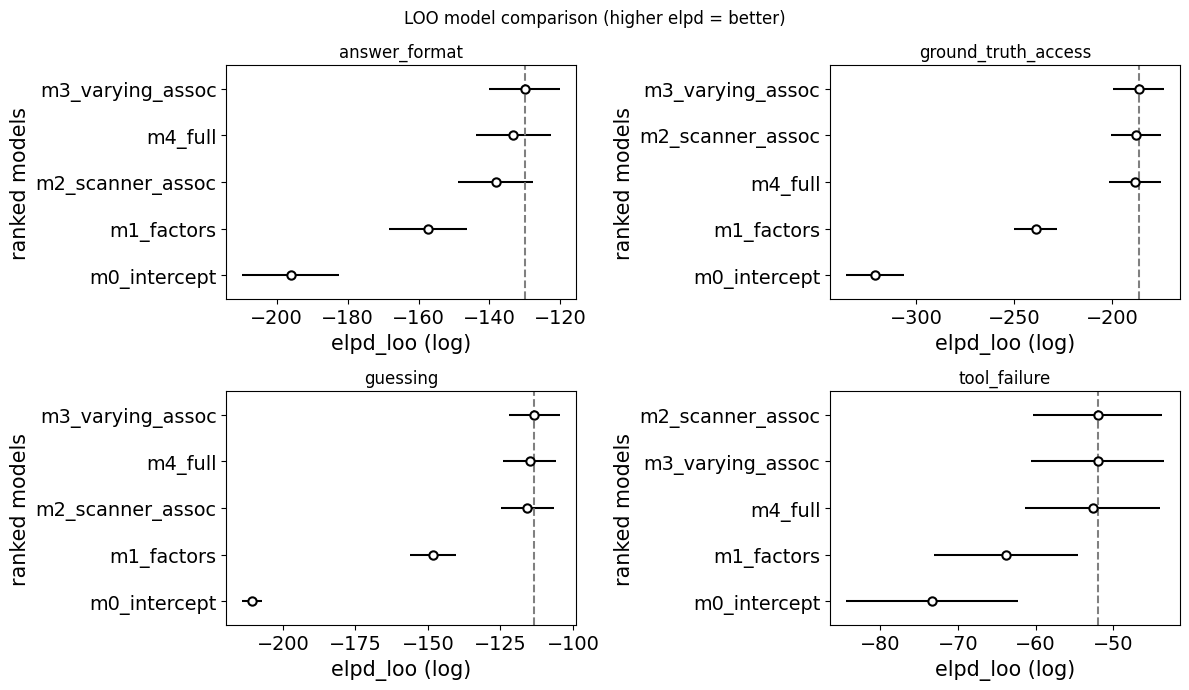

In [7]:
loo_tables = []
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, crit in zip(axes.ravel(), CRITERIA):
    run = crit_runs[crit]
    comp = az.compare(
        {name: fit["idata"] for name, fit in run["fits"].items()}, ic="loo"
    )
    display(Markdown(f"**{crit}** (n={len(run['frame']):,}, "
                     f"primary = {run['primary_name']})"))
    display(comp.round(2))
    loo_tables.append(comp.assign(criterion=crit))
    az.plot_compare(comp, ax=ax)
    ax.set_title(crit)
fig.suptitle("LOO model comparison (higher elpd = better)")
fig.tight_layout()

loo_all = pd.concat(loo_tables).rename_axis("model").reset_index()
if RESULTS_DIR is not None:
    loo_all.to_csv(RESULTS_DIR / "model_comparison_loo.csv", index=False)
    fig.savefig(RESULTS_DIR / "model_comparison_loo.png",
                dpi=150, bbox_inches="tight")
plt.show()

## 2. Coefficient tables (primary model, per criterion)

Posterior analogs of the requested frequentist columns:

- `estimate` — posterior mean (log-odds scale).
- `se` — posterior sd.
- `z` — estimate / se.
- `p_direction` — two-sided directional posterior probability,
  `2 · min(P(β>0), P(β<0))`; floored at `2/n_draws` (MCMC resolution).
- `ci_lo` / `ci_hi` — 95% equal-tailed credible interval.
- `odds_ratio` and its CI — `exp()` of the estimate and interval.

Interpretation under effect coding, within each criterion's fit (all
deviations on the **log-odds** scale, averaged over the other factor).
With the `m2_scanner_assoc` primary model the table has only:

- `Intercept` — that criterion's grand-average log-odds of
  `human_grade = 1` at the midpoint between scanner-negative and
  scanner-positive.
- `scanner_grade_centered` — the scanner–human association (the headline
  "does this scanner track humans" coefficient), shared across scanner
  models and benchmarks within the criterion.
- `scanner_model[...]` / `benchmark[...]` — level-specific deviations in
  the human-positive rate (baseline differences, not agreement
  differences).

(If `PRIMARY_MODEL` is set to a deeper rung, `scanner_grade_centered:…`
interaction terms appear as well, with the analogous "deviation in
association" reading.)

The omitted (alphabetically last) level of each factor has deviation equal
to minus the sum of the shown levels. Coefficients are **not comparable
across criteria at face value** beyond sign and rough magnitude — each fit
has its own intercept and (for the core_bench-only criteria) a smaller
design.

In [8]:
def coef_table_from(fit: dict) -> pd.DataFrame:
    draws = coef_draws_of(fit)
    n_draws = draws.shape[0]
    est = draws.mean(axis=0)
    se = draws.std(axis=0, ddof=1)
    p_gt = (draws > 0).mean(axis=0)
    p_two = np.maximum(2 * np.minimum(p_gt, 1 - p_gt), 2 / n_draws)
    lo, hi = np.quantile(draws, [0.025, 0.975], axis=0)
    return pd.DataFrame(
        {
            "estimate": est,
            "se": se,
            "z": est / se,
            "p_direction": p_two,
            "ci_lo": lo,
            "ci_hi": hi,
            "odds_ratio": np.exp(est),
            "or_ci_lo": np.exp(lo),
            "or_ci_hi": np.exp(hi),
        },
        index=pd.Index(fit["names"], name="term"),
    )


coef_tables = []
for crit in CRITERIA:
    run = crit_runs[crit]
    fit = run["fits"][run["primary_name"]]
    tab = coef_table_from(fit)
    display(Markdown(f"**{crit}** ({run['primary_name']})"))
    display(tab.round(3))
    coef_tables.append(tab.assign(criterion=crit).reset_index())
    if RESULTS_DIR is not None:
        fit["idata"].to_netcdf(RESULTS_DIR / f"idata_{crit}.nc")

coef_all = pd.concat(coef_tables, ignore_index=True)
if RESULTS_DIR is not None:
    coef_all.to_csv(RESULTS_DIR / "coefficient_table.csv", index=False)
    print(f"Saved coefficient tables + per-criterion idata to {RESULTS_DIR}")

**answer_format** (m2_scanner_assoc)

,estimate,se,z,p_direction,ci_lo,ci_hi,odds_ratio,or_ci_lo,or_ci_hi
term,,,,,,,,,
Intercept,-2.794,0.395,-7.082,0.001,-3.631,-2.113,0.061,0.026,0.121
scanner_grade_centered,1.913,0.315,6.076,0.001,1.293,2.537,6.774,3.645,12.643
scanner_model[S.gpt-5.4],-0.086,0.154,-0.560,0.550,-0.395,0.220,0.918,0.673,1.246
benchmark[S.core_bench],2.306,0.449,5.138,0.001,1.505,3.271,10.038,4.506,26.333
benchmark[S.cvebench],1.432,0.516,2.775,0.001,0.489,2.517,4.188,1.631,12.397
benchmark[S.gpqa_diamond],-1.024,0.968,-1.058,0.293,-3.111,0.716,0.359,0.045,2.046
benchmark[S.hle],1.868,0.449,4.163,0.001,1.034,2.864,6.476,2.813,17.532
benchmark[S.kernelbench],-1.823,0.867,-2.104,0.023,-3.749,-0.267,0.161,0.024,0.766
benchmark[S.swe_bench],0.666,0.543,1.227,0.200,-0.347,1.784,1.946,0.707,5.951


**ground_truth_access** (m2_scanner_assoc)

,estimate,se,z,p_direction,ci_lo,ci_hi,odds_ratio,or_ci_lo,or_ci_hi
term,,,,,,,,,
Intercept,-2.815,0.425,-6.624,0.001,-3.705,-2.068,0.060000,0.025,0.126
scanner_grade_centered,2.637,0.289,9.133,0.001,2.107,3.219,13.974000,8.221,25.000
scanner_model[S.gpt-5.4],-0.277,0.136,-2.035,0.043,-0.530,-0.013,0.758000,0.589,0.987
benchmark[S.core_bench],2.784,0.455,6.115,0.001,1.945,3.764,16.183001,6.990,43.128
benchmark[S.cvebench],-0.283,0.644,-0.440,0.658,-1.592,0.999,0.753000,0.204,2.717
benchmark[S.kernelbench],-0.571,0.918,-0.622,0.562,-2.444,1.036,0.565000,0.087,2.818
benchmark[S.swe_bench],2.199,0.444,4.956,0.001,1.414,3.119,9.014000,4.112,22.618


**guessing** (m2_scanner_assoc)

,estimate,se,z,p_direction,ci_lo,ci_hi,odds_ratio,or_ci_lo,or_ci_hi
term,,,,,,,,,
Intercept,0.133,0.270,0.493,0.641,-0.380,0.702,1.142000,0.684,2.017
scanner_grade_centered,2.647,0.375,7.058,0.001,1.932,3.386,14.115000,6.903,29.549
scanner_model[S.gpt-5.4],-0.230,0.173,-1.335,0.182,-0.569,0.101,0.794000,0.566,1.106
benchmark[S.core_bench],-0.672,0.317,-2.118,0.018,-1.342,-0.093,0.511000,0.261,0.911
benchmark[S.cvebench],-1.693,0.439,-3.861,0.001,-2.577,-0.873,0.184000,0.076,0.418
benchmark[S.gpqa_diamond],3.509,0.661,5.305,0.001,2.374,4.992,33.400002,10.737,147.200


**tool_failure** (m2_scanner_assoc)

,estimate,se,z,p_direction,ci_lo,ci_hi,odds_ratio,or_ci_lo,or_ci_hi
term,,,,,,,,,
Intercept,-3.070,0.437,-7.020,0.001,-4.018,-2.311,0.046000,0.018,0.099
scanner_grade_centered,2.817,0.656,4.295,0.001,1.544,4.104,16.726999,4.684,60.573
scanner_model[S.gpt-5.4],-0.622,0.310,-2.007,0.043,-1.235,-0.020,0.537000,0.291,0.981
benchmark[S.core_bench],-2.244,0.747,-3.002,0.002,-3.787,-0.875,0.106000,0.023,0.417
benchmark[S.cvebench],-1.030,0.889,-1.158,0.229,-2.912,0.565,0.357000,0.054,1.760
benchmark[S.kernelbench],2.226,0.515,4.325,0.001,1.251,3.236,9.260000,3.495,25.441


Saved coefficient tables + per-criterion idata to /home/jeffm/projects/scanner_evaluation/analysis/results/glm/glm_test_all


## 3. Marginal predicted probabilities

For every criterion × scanner_model × benchmark cell, predict at both
scanner grades (`scanner_grade_centered = ∓0.5`):

```
P(human_grade = 1 | scanner_grade = 0, scanner_model, benchmark)
P(human_grade = 1 | scanner_grade = 1, scanner_model, benchmark)
```

Each criterion's predictions come from its own fit, over its own benchmark
levels. Observed cell rates and counts are merged in for an informal
calibration check — cells with tiny `n` are where the priors do the most
shrinkage.

In [9]:
marginal_parts = []
for crit in CRITERIA:
    run = crit_runs[crit]
    fit = run["fits"][run["primary_name"]]
    draws = coef_draws_of(fit)

    grid = pd.DataFrame(
        [
            {"scanner_model": m, "benchmark": b, "scanner_grade": g}
            for m in run["levels"]["scanner_model"]
            for b in run["levels"]["benchmark"]
            for g in (0, 1)
        ]
    )
    grid["scanner_grade_centered"] = grid["scanner_grade"] - 0.5
    X_grid = build_design(
        grid, MODEL_TERMS[run["primary_name"]], run["levels"]
    ).to_numpy(dtype=float)
    p_grid = 1.0 / (1.0 + np.exp(-(draws @ X_grid.T)))  # (n_draws, n_cells)

    part = grid.copy()
    part.insert(0, "criterion", crit)
    part["p_human1"] = p_grid.mean(axis=0)
    part["se"] = p_grid.std(axis=0, ddof=1)
    part["ci_lo"] = np.quantile(p_grid, 0.025, axis=0)
    part["ci_hi"] = np.quantile(p_grid, 0.975, axis=0)
    marginal_parts.append(part)

marginal = pd.concat(marginal_parts, ignore_index=True)
emp = (
    df.groupby(["criterion", "scanner_model", "benchmark", "scanner_grade"], as_index=False)
    .agg(n=("human_grade", "size"), obs_rate=("human_grade", "mean"))
)
marginal = marginal.merge(
    emp, on=["criterion", "scanner_model", "benchmark", "scanner_grade"], how="left"
)
display(marginal.round(3))

if RESULTS_DIR is not None:
    marginal.to_csv(RESULTS_DIR / "marginal_probabilities.csv", index=False)

,criterion,scanner_model,benchmark,scanner_grade,scanner_grade_centered,p_human1,se,ci_lo,ci_hi,n,obs_rate
0,answer_format,gpt-5.4,core_bench,0,-0.5,0.184,0.051,0.096,0.293,25.0,0.240
1,answer_format,gpt-5.4,core_bench,1,0.5,0.592,0.082,0.418,0.741,12.0,0.583
2,answer_format,gpt-5.4,cvebench,0,-0.5,0.089,0.036,0.034,0.171,25.0,0.000
3,answer_format,gpt-5.4,cvebench,1,0.5,0.386,0.107,0.189,0.604,4.0,1.000
4,answer_format,gpt-5.4,gpqa_diamond,0,-0.5,0.012,0.013,0.001,0.048,25.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...
75,tool_failure,sonnet-4.6,cvebench,1,0.5,0.172,0.162,0.008,0.606,NaN,NaN
76,tool_failure,sonnet-4.6,kernelbench,0,-0.5,0.172,0.061,0.073,0.307,28.0,0.143
77,tool_failure,sonnet-4.6,kernelbench,1,0.5,0.740,0.140,0.416,0.940,1.0,1.000
78,tool_failure,sonnet-4.6,swe_bench,0,-0.5,0.063,0.030,0.021,0.136,49.0,0.082


## 4. Agreement summary

Per criterion × scanner_model, at the **grand-average benchmark** (the
`"(average)"` placeholder codes the effect-coded benchmark columns to zero,
which averages over benchmarks on the log-odds scale):

```
delta    = P(human=1 | scanner=1) − P(human=1 | scanner=0)
PPV-like = P(human=1 | scanner=1)
NPV-like = P(human=0 | scanner=0) = 1 − P(human=1 | scanner=0)
```

Reading `delta`:

- **Large positive** — scanner labels discriminate well between
  human-negative and human-positive cases.
- **Near zero** — scanner labels carry little information about human labels.
- **Negative** — scanner labels are inversely associated with human labels:
  severe disagreement or a coding problem.

`P(delta > 0)` is the posterior probability the scanner is positively
associated with the human grade in that cell.

Under the `m2_scanner_assoc` primary model the log-odds association is a
single coefficient per criterion, so within a criterion the two scanner
models' deltas differ **only through their baseline rates** (the logistic
curve is steepest near 0.5) — they are tied together, not independent
estimates. Per-scanner agreement differences beyond that would come from
the `m3`/`m4` interaction terms, which LOO did not support. Benchmark-level
breakouts live in the marginal table above (section 3).

,criterion,scanner_model,p_h1_s0,p_h1_s0_lo,p_h1_s0_hi,p_h1_s1,p_h1_s1_lo,p_h1_s1_hi,delta,delta_lo,delta_hi,P(delta>0),ppv,npv,npv_lo,npv_hi
0,answer_format,gpt-5.4,0.023,0.008,0.046,0.136,0.054,0.248,0.112,0.043,0.209,1.0,0.136,0.977,0.954,0.992
1,answer_format,sonnet-4.6,0.027,0.010,0.053,0.157,0.061,0.285,0.130,0.047,0.242,1.0,0.157,0.973,0.947,0.990
2,ground_truth_access,gpt-5.4,0.013,0.005,0.028,0.154,0.059,0.277,0.140,0.053,0.255,1.0,0.154,0.987,0.972,0.995
3,ground_truth_access,sonnet-4.6,0.023,0.008,0.046,0.239,0.096,0.408,0.216,0.086,0.366,1.0,0.239,0.977,0.954,0.992
4,guessing,gpt-5.4,0.202,0.100,0.343,0.767,0.634,0.874,0.566,0.437,0.682,1.0,0.767,0.798,0.657,0.900
5,guessing,sonnet-4.6,0.282,0.162,0.425,0.837,0.723,0.927,0.555,0.426,0.668,1.0,0.837,0.718,0.575,0.838
6,tool_failure,gpt-5.4,0.008,0.001,0.021,0.103,0.033,0.222,0.095,0.030,0.209,1.0,0.103,0.992,0.979,0.999
7,tool_failure,sonnet-4.6,0.023,0.007,0.051,0.282,0.077,0.591,0.259,0.066,0.563,1.0,0.282,0.977,0.949,0.993


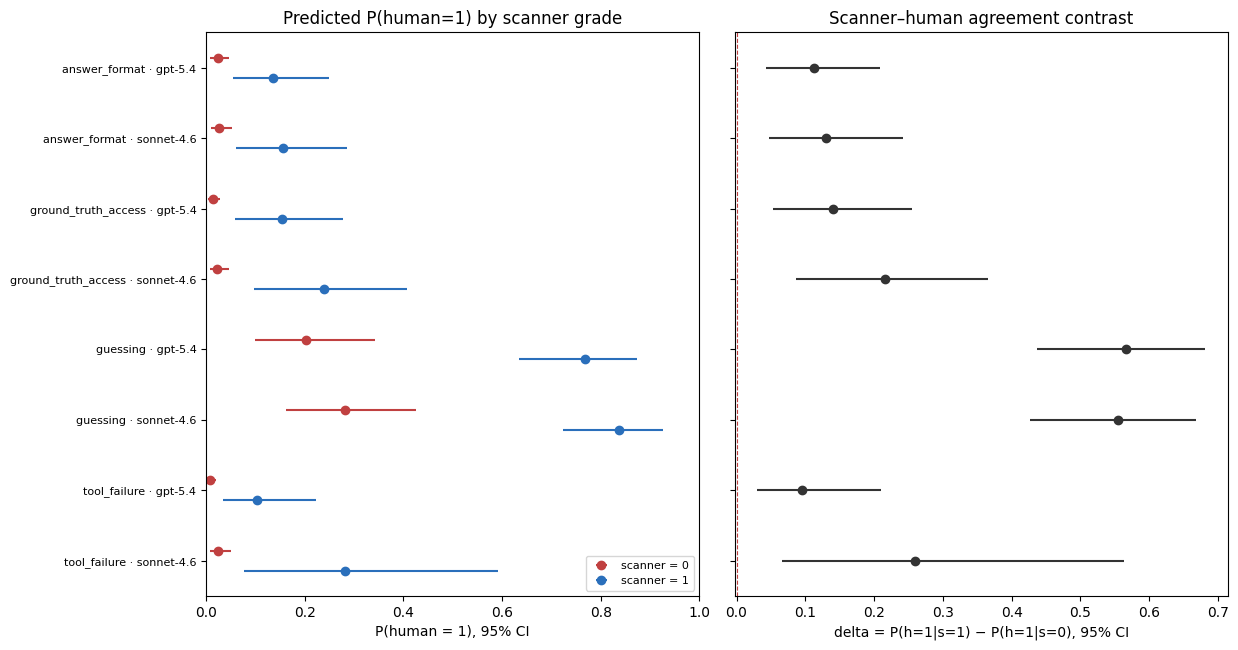

In [10]:
def _summ(draws: np.ndarray, prefix: str) -> dict[str, np.ndarray]:
    return {
        prefix: draws.mean(axis=0),
        f"{prefix}_lo": np.quantile(draws, 0.025, axis=0),
        f"{prefix}_hi": np.quantile(draws, 0.975, axis=0),
    }


agreement_parts = []
for crit in CRITERIA:
    run = crit_runs[crit]
    fit = run["fits"][run["primary_name"]]
    draws = coef_draws_of(fit)

    grid = pd.DataFrame(
        [
            {"scanner_model": m, "scanner_grade": g}
            for m in run["levels"]["scanner_model"]
            for g in (0, 1)
        ]
    )
    grid["scanner_grade_centered"] = grid["scanner_grade"] - 0.5
    grid["benchmark"] = "(average)"   # codes to all-zero benchmark columns
    X_grid = build_design(
        grid, MODEL_TERMS[run["primary_name"]], run["levels"]
    ).to_numpy(dtype=float)
    p_grid = 1.0 / (1.0 + np.exp(-(draws @ X_grid.T)))

    mask0 = grid["scanner_grade"].to_numpy() == 0
    # scanner_grade varies fastest in the grid, so the halves align cell-wise.
    p0 = p_grid[:, mask0]
    p1 = p_grid[:, ~mask0]
    delta = p1 - p0
    npv = 1.0 - p0

    part = grid.loc[mask0, ["scanner_model"]].reset_index(drop=True)
    part.insert(0, "criterion", crit)
    for col, vals in {
        **_summ(p0, "p_h1_s0"),
        **_summ(p1, "p_h1_s1"),
        **_summ(delta, "delta"),
        **_summ(npv, "npv"),
    }.items():
        part[col] = vals
    part["ppv"] = part["p_h1_s1"]
    part["P(delta>0)"] = (delta > 0).mean(axis=0)
    agreement_parts.append(part)

agreement = pd.concat(agreement_parts, ignore_index=True)
col_order = [
    "criterion", "scanner_model",
    "p_h1_s0", "p_h1_s0_lo", "p_h1_s0_hi",
    "p_h1_s1", "p_h1_s1_lo", "p_h1_s1_hi",
    "delta", "delta_lo", "delta_hi", "P(delta>0)",
    "ppv", "npv", "npv_lo", "npv_hi",
]
agreement = agreement[col_order]
display(agreement.round(3))

if RESULTS_DIR is not None:
    agreement.to_csv(RESULTS_DIR / "agreement_summary.csv", index=False)


labels = [
    f"{r.criterion} · {r.scanner_model}"
    for r in agreement.itertuples()
]
yloc = np.arange(len(agreement))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12.5, 0.55 * len(agreement) + 2.2), sharey=True
)
ax1.errorbar(
    agreement["p_h1_s0"], yloc - 0.14,
    xerr=[agreement["p_h1_s0"] - agreement["p_h1_s0_lo"],
          agreement["p_h1_s0_hi"] - agreement["p_h1_s0"]],
    fmt="o", color="#c04040", label="scanner = 0",
)
ax1.errorbar(
    agreement["p_h1_s1"], yloc + 0.14,
    xerr=[agreement["p_h1_s1"] - agreement["p_h1_s1_lo"],
          agreement["p_h1_s1_hi"] - agreement["p_h1_s1"]],
    fmt="o", color="#2a6fbb", label="scanner = 1",
)
ax1.set_yticks(yloc)
ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlim(0, 1)
ax1.invert_yaxis()
ax1.set_xlabel("P(human = 1), 95% CI")
ax1.set_title("Predicted P(human=1) by scanner grade")
ax1.legend(loc="lower right", fontsize=8)

ax2.errorbar(
    agreement["delta"], yloc,
    xerr=[agreement["delta"] - agreement["delta_lo"],
          agreement["delta_hi"] - agreement["delta"]],
    fmt="o", color="#333",
)
ax2.axvline(0, color="#c04040", lw=0.8, ls="--")
ax2.set_xlabel("delta = P(h=1|s=1) − P(h=1|s=0), 95% CI")
ax2.set_title("Scanner–human agreement contrast")

fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "agreement_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Posterior predictive check

For each criterion's primary model, simulate replicated human-grade vectors
(`y_rep ~ Bernoulli(sigmoid(X @ coef))`, one vector per posterior draw) and
compare per-group human-positive rates against the observed rates, where
groups are the scanner_model × scanner_grade cells behind the
PPV / NPV / delta summaries (pooled over benchmarks; each replicated row
still uses its own benchmark baseline, so the check compares the shared
association against each group's empirical benchmark mix).

`ppp` is a two-sided posterior predictive p-value,
`2 · min(P(rate_rep ≥ rate_obs), P(rate_rep ≤ rate_obs))` — values near 0
flag groups the model can't reproduce (a well-calibrated model gives
unremarkable mid-range values).

With the additive `m2_scanner_assoc` primary model this is a real test:
the model cannot fit each scanner_grade arm of each cell freely, so a cell
whose agreement genuinely deviates from the criterion's shared association
(exactly what the omitted `m3`/`m4` interaction terms would capture) shows
up here as a low `ppp`.

,criterion,scanner_model,scanner_grade,n,observed,pred_mean,pred_lo,pred_hi,ppp
0,answer_format,gpt-5.4,0,175,0.040,0.067,0.023,0.120,0.321
1,answer_format,gpt-5.4,1,63,0.429,0.361,0.222,0.492,0.395
2,answer_format,sonnet-4.6,0,184,0.098,0.079,0.038,0.130,0.489
3,answer_format,sonnet-4.6,1,53,0.302,0.375,0.226,0.509,0.388
4,ground_truth_access,gpt-5.4,0,200,0.050,0.070,0.030,0.115,0.454
5,ground_truth_access,gpt-5.4,1,133,0.391,0.367,0.278,0.451,0.641
6,ground_truth_access,sonnet-4.6,0,281,0.107,0.099,0.057,0.146,0.768
7,ground_truth_access,sonnet-4.6,1,52,0.615,0.669,0.519,0.808,0.535
8,guessing,gpt-5.4,0,77,0.039,0.100,0.039,0.195,0.113
9,guessing,gpt-5.4,1,79,0.759,0.698,0.570,0.810,0.380


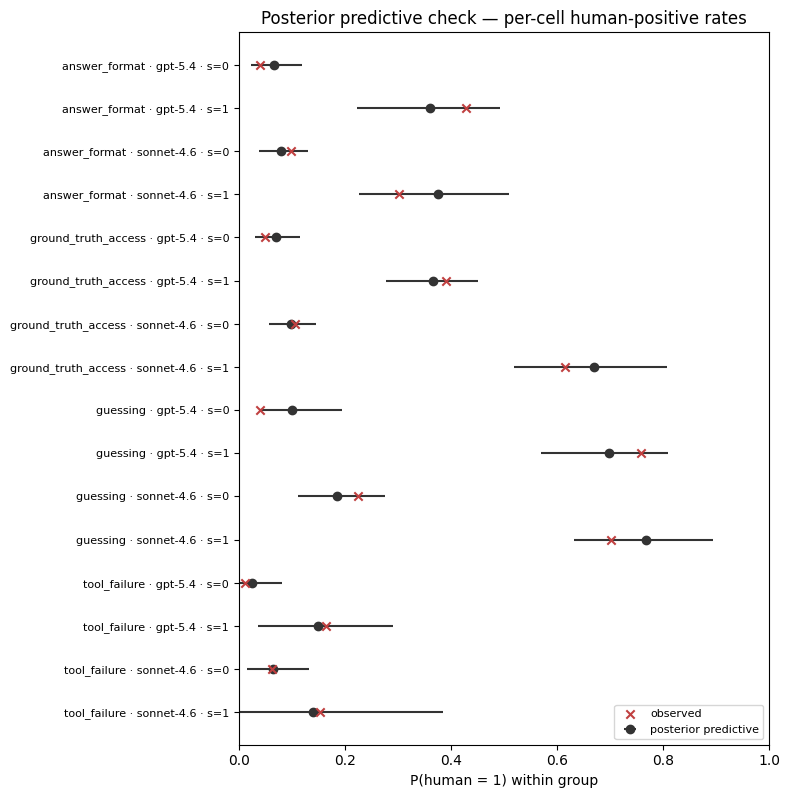

In [11]:
rng = np.random.default_rng(0)
ppc_parts = []
for crit in CRITERIA:
    run = crit_runs[crit]
    fit = run["fits"][run["primary_name"]]
    sub = run["frame"]
    draws = coef_draws_of(fit)
    p_row = 1.0 / (1.0 + np.exp(-(draws @ fit["X_df"].to_numpy(dtype=float).T)))
    y_rep = rng.binomial(1, p_row)  # (n_draws, n_obs)

    for key, g in sub.groupby(["scanner_model", "scanner_grade"]):
        idx = g.index.to_numpy()
        obs_rate = float(g["human_grade"].mean())
        rep_rates = y_rep[:, idx].mean(axis=1)
        ppp = 2 * min(
            float((rep_rates >= obs_rate).mean()),
            float((rep_rates <= obs_rate).mean()),
        )
        ppc_parts.append({
            "criterion": crit,
            **dict(zip(["scanner_model", "scanner_grade"], key)),
            "n": int(len(idx)),
            "observed": obs_rate,
            "pred_mean": float(rep_rates.mean()),
            "pred_lo": float(np.quantile(rep_rates, 0.025)),
            "pred_hi": float(np.quantile(rep_rates, 0.975)),
            "ppp": min(ppp, 1.0),
        })

ppc = pd.DataFrame(ppc_parts)
display(ppc.round(3))

if RESULTS_DIR is not None:
    ppc.to_csv(RESULTS_DIR / "ppc_rates.csv", index=False)

yp = np.arange(len(ppc))
fig, ax = plt.subplots(figsize=(8, 0.38 * len(ppc) + 2.0))
ax.errorbar(
    ppc["pred_mean"], yp,
    xerr=[ppc["pred_mean"] - ppc["pred_lo"],
          ppc["pred_hi"] - ppc["pred_mean"]],
    fmt="o", color="#333", label="posterior predictive",
)
ax.scatter(ppc["observed"], yp, marker="x", color="#c04040",
           zorder=3, label="observed")
ax.set_yticks(yp)
ax.set_yticklabels(
    [f"{r.criterion} · {r.scanner_model} · s={r.scanner_grade}"
     for r in ppc.itertuples()],
    fontsize=8,
)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("P(human = 1) within group")
ax.set_title("Posterior predictive check — per-cell human-positive rates")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "ppc_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## How to read the results

- **Lead with the agreement summary**: `delta` (with its CI) per
  criterion × scanner_model is the headline scanner-quality number;
  `ppv` / `npv` say what a positive / negative scanner label is worth in
  that cell. Benchmark-level detail stays in the marginal table (section 3). The coefficient tables are for inference about
  *deviations from each criterion's average pattern*, not for communicating
  agreement directly — effect-coded coefficients live on the log-odds scale.
- Because the four fits are fully independent, cross-criterion statements
  ("scanner agreement is better for ground_truth_access than tool_failure")
  are comparisons of independent posteriors — valid, but each side carries
  its own (sometimes wide) uncertainty.
- The **LOO ladders** justified the primary-model choice: the agreement
  interactions (`m3`/`m4`) don't clear their `dse` in any criterion, so the
  reported quantities come from `m2_scanner_assoc`. Per-cell deltas within
  a criterion are therefore baseline-rate translations of one shared
  association, not independent per-cell estimates.
- The **PPC** flags groups a model can't reproduce (`ppp` near 0) — under
  the additive primary model, that's where cell-specific agreement
  structure would announce itself.
- A wide CI on `delta` usually traces back to a small `n` in one of the two
  scanner-grade arms of that cell (see the `n` column in the marginal
  table). This bites hardest for the core_bench-only criteria (90
  observations each).

### Possible extensions

- Per-(transcript) random intercept within each criterion to respect the
  pairing of the two scanner models grading the same items (as
  `scanner_glm.ipynb` does); without it the two scanner rows per item are
  treated as independent, which can make CIs slightly optimistic.
- If cross-criterion comparisons become a primary question, a hierarchical
  model with partial pooling over criteria would sharpen the small-n
  criteria — at the cost of reintroducing the shared structure deliberately
  avoided here.

## Display figures

Polished versions of the headline results, intended for slides / writeups.
Scanner-model color scheme throughout: **burnt orange = sonnet**,
**dark green = gpt**.

1. **Agreement contrast** — `delta` per criterion with the two scanner
   models adjacent, so each criterion's performance reads as one visual
   group regardless of model.
2. **What a scanner label does to the human-violation probability** —
   dumbbells from `P(human=1 | scanner=0)` (open marker) to
   `P(human=1 | scanner=1)` (filled marker); long dumbbells = informative
   scanner, and the filled marker is the PPV-like quantity while
   `1 −` the open marker is the NPV-like quantity.
3. **Shared scanner–human association (odds ratio)** — under the
   `m2_scanner_assoc` primary model the association is a single coefficient
   per criterion, common to both scanner models, so this is the cleanest
   "how good is this scanner criterion, regardless of model" summary.
4. **Operational impact** — if human review were concentrated on scanner
   positives: review workload (fraction of transcripts flagged) vs issue
   capture (fraction of human-identified issues inside the flagged set),
   with the lift over unscreened review.

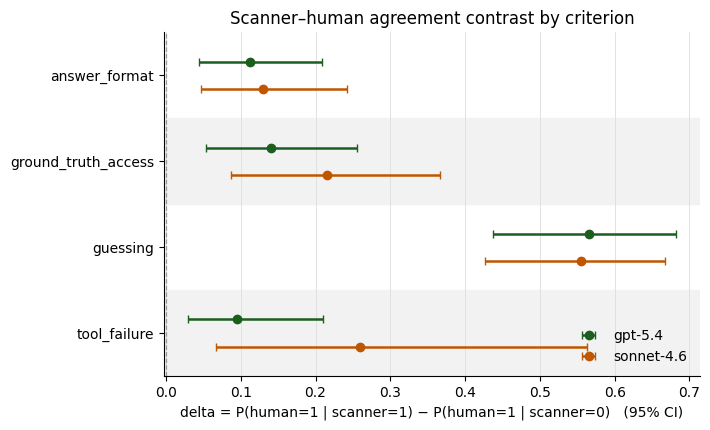

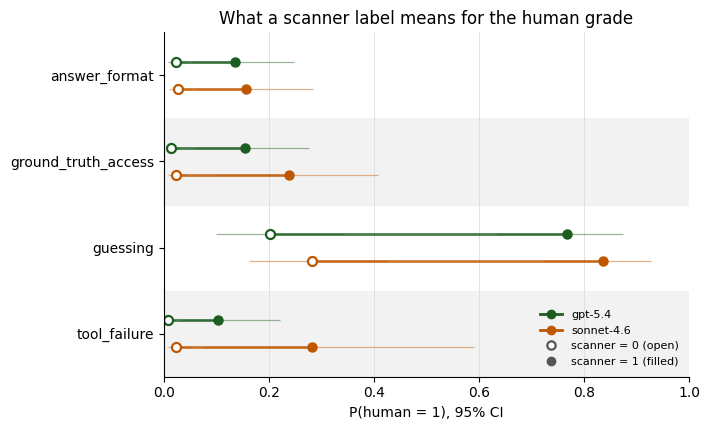

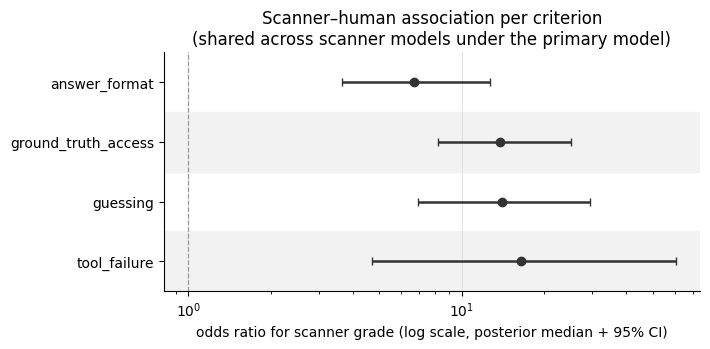

In [12]:
MODEL_COLOR = {
    m: ("#BF5700" if m.lower().startswith(("sonnet", "claude", "opus"))
        else "#1B5E20")
    for m in sorted(df["scanner_model"].unique())
}
display_models = sorted(MODEL_COLOR)
offsets = np.linspace(-0.16, 0.16, len(display_models))


def _criterion_axis(ax, n_rows):
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(CRITERIA)
    for i in range(n_rows):
        if i % 2:
            ax.axhspan(i - 0.5, i + 0.5, color="#f2f2f2", zorder=0)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#dddddd", lw=0.6)
    ax.set_axisbelow(True)


# --- Figure 1: agreement contrast, models grouped within criterion ---
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for off, m in zip(offsets, display_models):
    sm = (agreement[agreement["scanner_model"] == m]
          .set_index("criterion").reindex(CRITERIA))
    ypos = np.arange(len(CRITERIA)) + off
    ax.errorbar(
        sm["delta"], ypos,
        xerr=[sm["delta"] - sm["delta_lo"], sm["delta_hi"] - sm["delta"]],
        fmt="o", color=MODEL_COLOR[m], ms=6, lw=1.8, capsize=3, label=m,
    )
_criterion_axis(ax, len(CRITERIA))
ax.axvline(0, color="#999999", lw=0.9, ls="--")
ax.set_xlabel("delta = P(human=1 | scanner=1) − P(human=1 | scanner=0)   (95% CI)")
ax.set_title("Scanner–human agreement contrast by criterion")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "display_agreement_contrast.png",
                dpi=300, bbox_inches="tight")
plt.show()

# --- Figure 2: dumbbell P(human=1) at scanner=0 -> scanner=1 ---
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for off, m in zip(offsets, display_models):
    sm = (agreement[agreement["scanner_model"] == m]
          .set_index("criterion").reindex(CRITERIA))
    ypos = np.arange(len(CRITERIA)) + off
    color = MODEL_COLOR[m]
    ax.hlines(ypos, sm["p_h1_s0"], sm["p_h1_s1"], color=color, lw=2, alpha=0.8)
    for col, lo, hi in [("p_h1_s0", "p_h1_s0_lo", "p_h1_s0_hi"),
                        ("p_h1_s1", "p_h1_s1_lo", "p_h1_s1_hi")]:
        ax.errorbar(sm[col], ypos,
                    xerr=[sm[col] - sm[lo], sm[hi] - sm[col]],
                    fmt="none", ecolor=color, elinewidth=0.9, alpha=0.45)
    ax.plot(sm["p_h1_s0"], ypos, "o", ms=6.5, mfc="white", mec=color, mew=1.6)
    ax.plot(sm["p_h1_s1"], ypos, "o", ms=6.5, color=color)
_criterion_axis(ax, len(CRITERIA))
ax.set_xlim(0, 1)
ax.set_xlabel("P(human = 1), 95% CI")
ax.set_title("What a scanner label means for the human grade")
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([], [], color=MODEL_COLOR[m], marker="o", lw=2, label=m)
    for m in display_models
] + [
    Line2D([], [], color="#555555", marker="o", mfc="white", mew=1.6, ls="",
           label="scanner = 0 (open)"),
    Line2D([], [], color="#555555", marker="o", ls="", label="scanner = 1 (filled)"),
]
ax.legend(handles=legend_handles, frameon=False, loc="lower right", fontsize=8)
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "display_label_value.png",
                dpi=300, bbox_inches="tight")
plt.show()

# --- Figure 3: shared association odds ratio per criterion ---
or_rows = []
for crit in CRITERIA:
    run = crit_runs[crit]
    fit = run["fits"][run["primary_name"]]
    i = fit["names"].index(SGC)
    d = np.exp(coef_draws_of(fit)[:, i])
    or_rows.append({
        "criterion": crit,
        "or_median": float(np.median(d)),
        "or_lo": float(np.quantile(d, 0.025)),
        "or_hi": float(np.quantile(d, 0.975)),
    })
or_df = pd.DataFrame(or_rows)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ypos = np.arange(len(or_df))
ax.errorbar(
    or_df["or_median"], ypos,
    xerr=[or_df["or_median"] - or_df["or_lo"],
          or_df["or_hi"] - or_df["or_median"]],
    fmt="o", color="#333333", ms=6, lw=1.8, capsize=3,
)
_criterion_axis(ax, len(or_df))
ax.set_xscale("log")
ax.axvline(1, color="#999999", lw=0.9, ls="--")
ax.set_xlabel("odds ratio for scanner grade (log scale, posterior median + 95% CI)")
ax.set_title("Scanner–human association per criterion\n(shared across scanner models under the primary model)")
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "display_association_or.png",
                dpi=300, bbox_inches="tight")
    or_df.to_csv(RESULTS_DIR / "display_association_or.csv", index=False)
plt.show()

### Operational impact — triage value of the scanner flags

Translation of the fit into a review-allocation statement: *"reviewing only
the X% of transcripts the scanner flags would catch Y% of human-identified
issues, a Z× higher yield per review than unscreened review."*

Derivation (per criterion × scanner_model, from the primary model):

- Each observation keeps its **actual flag**; the model supplies
  `p_i = P(human=1 | x_i)` per posterior draw.
- **workload** = fraction of transcripts flagged (empirical, no
  uncertainty).
- **capture** = Σ flagged `p_i` / Σ all `p_i` per draw — the model-expected
  fraction of true issues that sit inside the flagged set. This is the
  Bayes-consistent sensitivity `P(scanner=1 | human=1)` under the empirical
  flag pattern and benchmark mix.
- **lift** = (mean `p_i` over flagged) / (mean `p_i` over all) per draw —
  yield per reviewed transcript relative to reviewing everything /
  at random. Note this is deliberately *not* the relative risk
  (PPV / P(h=1|s=0)), which compares against reviewing only unflagged
  transcripts and overstates the practical gain.
- **missed_per_100** = model-expected issues left in the *unflagged* pool
  per 100 transcripts scanned — the absolute miss burden of a
  review-the-flags-only policy (see the missed-issues section below for
  the detection-side analysis).

In the scatter, the dashed diagonal is the random-review baseline
(reviewing X% of transcripts at random captures X% of issues in
expectation); vertical distance above it is the enrichment the scanner
buys. Caveats: the flag pattern and benchmark mix are taken as observed,
the flag *rate* itself is not modelled, and some cells are small.

,criterion,scanner_model,n,n_flagged,workload,capture,capture_lo,capture_hi,lift,lift_lo,lift_hi,missed_per_100,missed_per_100_lo,missed_per_100_hi
0,answer_format,gpt-5.4,238,63,0.265,0.663,0.566,0.763,2.506,2.139,2.883,4.896,2.888,7.390
1,answer_format,sonnet-4.6,237,53,0.224,0.579,0.484,0.683,2.591,2.165,3.055,6.150,3.780,8.882
2,ground_truth_access,gpt-5.4,333,133,0.399,0.777,0.709,0.842,1.945,1.774,2.107,4.221,2.703,6.147
3,ground_truth_access,sonnet-4.6,333,52,0.156,0.557,0.491,0.632,3.568,3.144,4.049,8.360,5.997,11.077
4,guessing,gpt-5.4,156,79,0.506,0.878,0.825,0.922,1.733,1.628,1.820,4.954,2.882,7.657
5,guessing,sonnet-4.6,155,57,0.368,0.705,0.646,0.764,1.918,1.755,2.078,11.837,8.480,15.734
6,tool_failure,gpt-5.4,142,55,0.387,0.792,0.597,0.926,2.046,1.541,2.390,1.538,0.443,3.438
7,tool_failure,sonnet-4.6,142,13,0.092,0.184,0.094,0.323,2.015,1.023,3.523,5.892,2.853,10.002


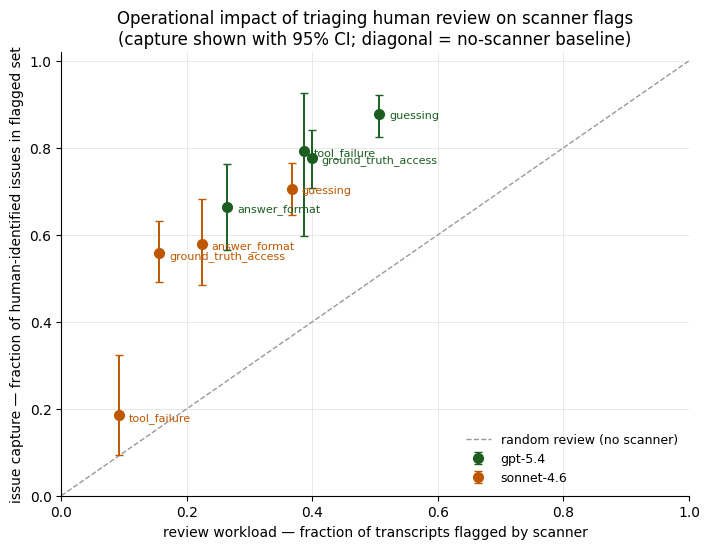

In [13]:
op_rows = []
for crit in CRITERIA:
    run = crit_runs[crit]
    fit = run["fits"][run["primary_name"]]
    sub = run["frame"]
    draws = coef_draws_of(fit)
    p_row = 1.0 / (1.0 + np.exp(-(draws @ fit["X_df"].to_numpy(dtype=float).T)))

    for m, g in sub.groupby("scanner_model"):
        idx = g.index.to_numpy()
        flagged = g[g["scanner_grade"] == 1].index.to_numpy()
        p_all = p_row[:, idx]
        p_flag = p_row[:, flagged]

        expected_issues = p_all.sum(axis=1)
        capture = p_flag.sum(axis=1) / expected_issues
        lift = p_flag.mean(axis=1) / p_all.mean(axis=1)
        # Issues left in the unflagged pool, per 100 transcripts scanned.
        missed_per_100 = (expected_issues - p_flag.sum(axis=1)) / len(idx) * 100

        op_rows.append({
            "criterion": crit,
            "scanner_model": m,
            "n": int(len(idx)),
            "n_flagged": int(len(flagged)),
            "workload": len(flagged) / len(idx),
            "capture": float(capture.mean()),
            "capture_lo": float(np.quantile(capture, 0.025)),
            "capture_hi": float(np.quantile(capture, 0.975)),
            "lift": float(lift.mean()),
            "lift_lo": float(np.quantile(lift, 0.025)),
            "lift_hi": float(np.quantile(lift, 0.975)),
            "missed_per_100": float(missed_per_100.mean()),
            "missed_per_100_lo": float(np.quantile(missed_per_100, 0.025)),
            "missed_per_100_hi": float(np.quantile(missed_per_100, 0.975)),
        })

operational = pd.DataFrame(op_rows)
display(operational.round(3))

if RESULTS_DIR is not None:
    operational.to_csv(RESULTS_DIR / "display_operational_impact.csv", index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.plot([0, 1], [0, 1], ls="--", color="#999999", lw=1,
        label="random review (no scanner)")
for m in display_models:
    sm = operational[operational["scanner_model"] == m]
    color = MODEL_COLOR[m]
    ax.errorbar(
        sm["workload"], sm["capture"],
        yerr=[sm["capture"] - sm["capture_lo"], sm["capture_hi"] - sm["capture"]],
        fmt="o", color=color, ms=7, lw=1.4, capsize=3, label=m,
    )
    for r in sm.itertuples():
        ax.annotate(
            r.criterion, (r.workload, r.capture),
            xytext=(7, -3), textcoords="offset points",
            fontsize=8, color=color,
        )
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e5e5e5", lw=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("review workload — fraction of transcripts flagged by scanner")
ax.set_ylabel("issue capture — fraction of human-identified issues in flagged set")
ax.set_title("Operational impact of triaging human review on scanner flags\n(capture shown with 95% CI; diagonal = no-scanner baseline)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "display_operational_impact.png",
                dpi=300, bbox_inches="tight")
plt.show()

## Missed issues — detection-side analysis

Everything above conditions on the scanner ("what is a flag worth?"), so
misses appear only indirectly (NPV, capture). This section flips the
conditioning to *"given a human-identified issue, did the scanner find
it?"* with a **mirror GLM**, fit independently per criterion exactly like
the primary analysis:

```
scanner_grade ~ human_grade_centered * scanner_model    (+ benchmark)    (per criterion)
```

- Binary outcome: the **scanner flag**. Covariate:
  `human_grade_centered = human_grade − 0.5`.
- Marginal predictions give the miss-side quantities directly:
  - `P(scanner=1 | human=1)` — **sensitivity** (1 − this = miss rate)
  - `P(scanner=1 | human=0)` — **false-alarm rate**
  - their difference — **Youden's J / informedness**, the
    detection-direction twin of the risk-difference contrast above.
- A small ladder is LOO-compared as before, but the primary detection
  model **keeps the `human_grade_centered:scanner_model` interaction
  regardless**: per-model sensitivity is the question of interest here,
  unlike the confirmation direction where the shared-association model
  was the point. Treat per-model differences with LOO-proportional
  caution.

Sample-size warning: sensitivity is estimated from **human positives
only** (≈ 20–70 per criterion), so expect wide intervals — that is the
honest uncertainty of the miss rate, not a modelling artifact.

| model | adds |
|---|---|
| `d0_intercept` | intercept only |
| `d1_factors` | `scanner_model + benchmark` (flag-rate baselines) |
| `d2_detection` | `+ human_grade_centered` (does the scanner respond to true issues?) |
| `d3_varying_detection` *(primary)* | `+ human_grade_centered:scanner_model` (does sensitivity differ by model?) |

In [14]:
HGC = "human_grade_centered"
_d_factors = [("scanner_model",), ("benchmark",)]
DETECT_TERMS: dict[str, list[tuple[str, ...]]] = {
    "d0_intercept": [],
    "d1_factors": _d_factors,
    "d2_detection": [(HGC,)] + _d_factors,
    "d3_varying_detection": [(HGC,)] + _d_factors + [(HGC, "scanner_model")],
}
DETECT_PRIMARY = "d3_varying_detection"

detect_runs: dict[str, dict] = {}
for crit in CRITERIA:
    sub = crit_runs[crit]["frame"].copy()
    sub[HGC] = sub["human_grade"] - 0.5
    levels = crit_runs[crit]["levels"]
    print(f"[{crit}]  n={len(sub):,} · human positives={int(sub['human_grade'].sum())}")
    fits: dict[str, dict] = {}
    seen: dict[tuple, str] = {}
    for model_name, terms in DETECT_TERMS.items():
        Xd = build_design(sub, terms, levels)
        sig = tuple(Xd.columns)
        if sig in seen:
            print(f"    {model_name:<22} skipped (design identical to {seen[sig]})")
            continue
        seen[sig] = model_name
        fits[model_name] = fit_glm(sub, Xd, model_name, outcome="scanner_grade")
    primary_name = DETECT_PRIMARY if DETECT_PRIMARY in fits else list(fits)[-1]
    detect_runs[crit] = {
        "frame": sub, "levels": levels, "fits": fits, "primary_name": primary_name,
    }
    print(f"    primary model: {primary_name}\n")

detect_loo_tables = []
for crit in CRITERIA:
    run = detect_runs[crit]
    comp = az.compare(
        {name: fit["idata"] for name, fit in run["fits"].items()}, ic="loo"
    )
    display(Markdown(f"**LOO — {crit}**"))
    display(comp.round(2))
    detect_loo_tables.append(comp.assign(criterion=crit))

detect_loo_all = pd.concat(detect_loo_tables).rename_axis("model").reset_index()
if RESULTS_DIR is not None:
    detect_loo_all.to_csv(RESULTS_DIR / "detection_model_comparison_loo.csv", index=False)

[answer_format]  n=475 · human positives=68
    d0_intercept       1 cols · max r_hat 1.000 · min bulk ESS   592
    d1_factors         8 cols · max r_hat 1.000 · min bulk ESS   983
    d2_detection       9 cols · max r_hat 1.000 · min bulk ESS  1197
    d3_varying_detection 10 cols · max r_hat 1.000 · min bulk ESS  1190
    primary model: d3_varying_detection

[ground_truth_access]  n=666 · human positives=124
    d0_intercept       1 cols · max r_hat 1.010 · min bulk ESS   698
    d1_factors         6 cols · max r_hat 1.000 · min bulk ESS   613
    d2_detection       7 cols · max r_hat 1.000 · min bulk ESS   616
    d3_varying_detection  8 cols · max r_hat 1.010 · min bulk ESS   651
    primary model: d3_varying_detection

[guessing]  n=311 · human positives=125
    d0_intercept       1 cols · max r_hat 1.000 · min bulk ESS   694
    d1_factors         5 cols · max r_hat 1.000 · min bulk ESS   951
    d2_detection       6 cols · max r_hat 1.000 · min bulk ESS  1186
    d3_varying_det

**LOO — answer_format**

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
d3_varying_detection,0,-226.54,9.66,0.00,0.83,12.18,0.00,False,log
d2_detection,1,-228.96,8.59,2.42,0.12,12.08,2.75,False,log
d1_factors,2,-248.02,7.67,21.48,0.02,11.27,7.12,False,log
d0_intercept,3,-265.07,1.02,38.53,0.03,10.62,8.80,False,log


**LOO — ground_truth_access**

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
d2_detection,0,-286.63,6.07,0.00,0.97,13.98,0.00,False,log
d3_varying_detection,1,-287.56,7.00,0.93,0.00,14.04,0.10,False,log
d1_factors,2,-342.38,5.03,55.75,0.03,12.19,10.31,False,log
d0_intercept,3,-394.56,1.06,107.93,0.00,11.07,12.51,False,log


**LOO — guessing**

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
d3_varying_detection,0,-139.45,6.65,0.00,0.95,9.96,0.00,False,log
d2_detection,1,-144.27,5.81,4.82,0.04,9.70,3.29,False,log
d1_factors,2,-177.10,4.77,37.66,0.00,7.47,7.94,False,log
d0_intercept,3,-214.12,1.00,74.67,0.01,2.18,9.85,False,log


**LOO — tool_failure**

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
d3_varying_detection,0,-102.09,6.01,0.00,0.61,8.67,0.00,False,log
d2_detection,1,-102.21,4.85,0.13,0.39,8.36,1.74,False,log
d1_factors,2,-113.50,4.48,11.41,0.00,9.18,4.05,False,log
d0_intercept,3,-157.32,0.99,55.23,0.00,8.30,8.32,False,log


### Sensitivity, miss rate, and Youden's J

Marginal predictions from each criterion's primary detection model at the
grand-average benchmark, per scanner model. In the left panel, the **open
marker is the false-alarm rate** and the **filled marker is the
sensitivity** — the gap between them is the scanner's detection skill
(zero gap = the scanner flags issues and non-issues at the same rate).
The right panel shows Youden's J = sensitivity − false-alarm rate with
95% CI.

,criterion,scanner_model,sensitivity,sensitivity_lo,sensitivity_hi,miss_rate,miss_rate_lo,miss_rate_hi,false_alarm,false_alarm_lo,false_alarm_hi,youden_j,youden_j_lo,youden_j_hi,P(J>0)
0,answer_format,gpt-5.4,0.699,0.503,0.867,0.301,0.133,0.497,0.136,0.092,0.186,0.563,0.359,0.729,1.000
1,answer_format,sonnet-4.6,0.356,0.195,0.544,0.644,0.456,0.805,0.139,0.094,0.191,0.216,0.060,0.409,0.998
2,ground_truth_access,gpt-5.4,0.783,0.632,0.900,0.217,0.100,0.368,0.179,0.118,0.245,0.604,0.456,0.725,1.000
3,ground_truth_access,sonnet-4.6,0.405,0.249,0.569,0.595,0.431,0.751,0.037,0.020,0.061,0.368,0.219,0.529,1.000
4,guessing,gpt-5.4,0.917,0.828,0.977,0.083,0.023,0.172,0.185,0.102,0.288,0.733,0.603,0.843,1.000
5,guessing,sonnet-4.6,0.537,0.383,0.681,0.463,0.319,0.617,0.161,0.089,0.253,0.376,0.203,0.546,1.000
6,tool_failure,gpt-5.4,0.883,0.652,0.987,0.117,0.013,0.348,0.215,0.126,0.319,0.668,0.416,0.819,1.000
7,tool_failure,sonnet-4.6,0.182,0.027,0.467,0.818,0.533,0.973,0.030,0.012,0.056,0.153,-0.005,0.432,0.966


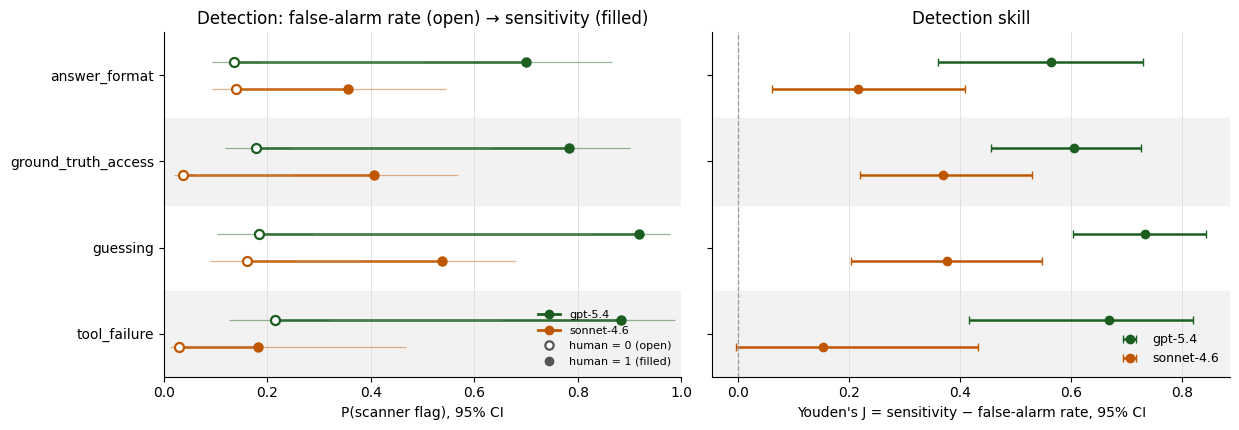

In [15]:
detect_parts = []
for crit in CRITERIA:
    run = detect_runs[crit]
    fit = run["fits"][run["primary_name"]]
    draws = coef_draws_of(fit)

    grid = pd.DataFrame(
        [
            {"scanner_model": m, "human_grade": h}
            for m in run["levels"]["scanner_model"]
            for h in (0, 1)
        ]
    )
    grid[HGC] = grid["human_grade"] - 0.5
    grid["benchmark"] = "(average)"   # codes to all-zero benchmark columns
    X_grid = build_design(
        grid, DETECT_TERMS[run["primary_name"]], run["levels"]
    ).to_numpy(dtype=float)
    p_grid = 1.0 / (1.0 + np.exp(-(draws @ X_grid.T)))

    mask0 = grid["human_grade"].to_numpy() == 0
    far = p_grid[:, mask0]            # P(flag | human=0)
    sens = p_grid[:, ~mask0]          # P(flag | human=1)
    youden = sens - far
    miss = 1.0 - sens

    part = grid.loc[mask0, ["scanner_model"]].reset_index(drop=True)
    part.insert(0, "criterion", crit)
    for col, vals in {
        **_summ(sens, "sensitivity"),
        **_summ(miss, "miss_rate"),
        **_summ(far, "false_alarm"),
        **_summ(youden, "youden_j"),
    }.items():
        part[col] = vals
    part["P(J>0)"] = (youden > 0).mean(axis=0)
    detect_parts.append(part)

detection = pd.concat(detect_parts, ignore_index=True)
display(detection.round(3))

if RESULTS_DIR is not None:
    detection.to_csv(RESULTS_DIR / "detection_summary.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for off, m in zip(offsets, display_models):
    sm = (detection[detection["scanner_model"] == m]
          .set_index("criterion").reindex(CRITERIA))
    ypos = np.arange(len(CRITERIA)) + off
    color = MODEL_COLOR[m]
    ax1.hlines(ypos, sm["false_alarm"], sm["sensitivity"],
               color=color, lw=2, alpha=0.8)
    for col, lo, hi in [("false_alarm", "false_alarm_lo", "false_alarm_hi"),
                        ("sensitivity", "sensitivity_lo", "sensitivity_hi")]:
        ax1.errorbar(sm[col], ypos,
                     xerr=[sm[col] - sm[lo], sm[hi] - sm[col]],
                     fmt="none", ecolor=color, elinewidth=0.9, alpha=0.45)
    ax1.plot(sm["false_alarm"], ypos, "o", ms=6.5, mfc="white", mec=color, mew=1.6)
    ax1.plot(sm["sensitivity"], ypos, "o", ms=6.5, color=color)
    ax2.errorbar(
        sm["youden_j"], ypos,
        xerr=[sm["youden_j"] - sm["youden_j_lo"],
              sm["youden_j_hi"] - sm["youden_j"]],
        fmt="o", color=color, ms=6, lw=1.8, capsize=3, label=m,
    )
for ax in (ax1, ax2):
    _criterion_axis(ax, len(CRITERIA))
ax1.set_xlim(0, 1)
ax1.set_xlabel("P(scanner flag), 95% CI")
ax1.set_title("Detection: false-alarm rate (open) → sensitivity (filled)")
legend_handles = [
    Line2D([], [], color=MODEL_COLOR[m], marker="o", lw=2, label=m)
    for m in display_models
] + [
    Line2D([], [], color="#555555", marker="o", mfc="white", mew=1.6, ls="",
           label="human = 0 (open)"),
    Line2D([], [], color="#555555", marker="o", ls="", label="human = 1 (filled)"),
]
ax1.legend(handles=legend_handles, frameon=False, loc="lower right", fontsize=8)
ax2.axvline(0, color="#999999", lw=0.9, ls="--")
ax2.set_xlabel("Youden's J = sensitivity − false-alarm rate, 95% CI")
ax2.set_title("Detection skill")
ax2.legend(frameon=False, loc="lower right", fontsize=9)
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "display_detection.png", dpi=300, bbox_inches="tight")
plt.show()

### Detection by severity

Empirical flag rates against the **ordinal** human grade (which the binary
analysis discards): are missed issues borderline cases sitting at the
binarization threshold, or do scanners also miss severe ones? Points show
the observed flag rate per (criterion, scanner_model, ordinal grade) with
Jeffreys 95% intervals; the dashed vertical line marks the binarization
threshold (grades to its right count as human-confirmed violations).
Marker area scales with the number of transcripts at that grade.

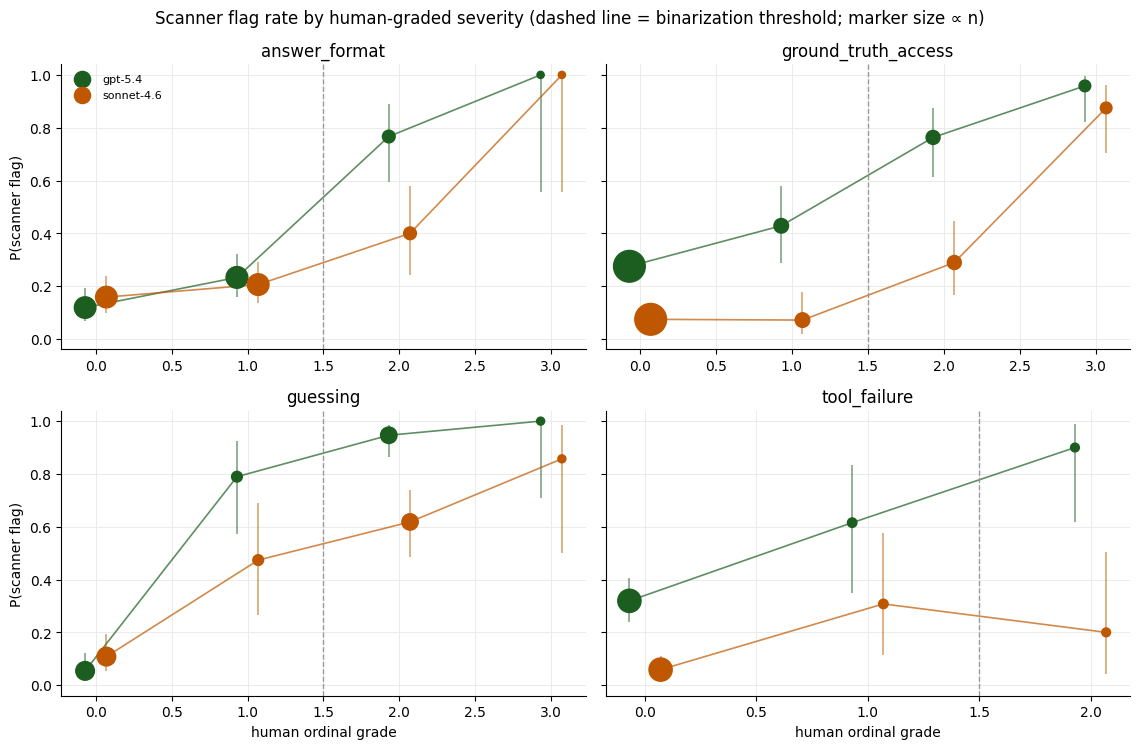

In [16]:
from scipy.stats import beta as beta_dist

sev_rows = []
for crit in CRITERIA:
    sub = detect_runs[crit]["frame"]
    for (m, hg), g in sub.groupby(["scanner_model", "human_grade_ord"]):
        n, k = len(g), int(g["scanner_grade"].sum())
        rate = k / n
        # Clip the Jeffreys interval to include the point estimate (it can
        # exclude rates of exactly 0 or 1 at boundary cells).
        sev_rows.append({
            "criterion": crit, "scanner_model": m, "human_grade_ord": hg,
            "n": n, "flag_rate": rate,
            "lo": min(rate, float(beta_dist.ppf(0.025, k + 0.5, n - k + 0.5))),
            "hi": max(rate, float(beta_dist.ppf(0.975, k + 0.5, n - k + 0.5))),
        })
severity = pd.DataFrame(sev_rows)

if RESULTS_DIR is not None:
    severity.to_csv(RESULTS_DIR / "detection_by_severity.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6), sharey=True)
for ax, crit in zip(axes.ravel(), CRITERIA):
    for off, m in zip((-0.07, 0.07), display_models):
        sm = severity[(severity["criterion"] == crit)
                      & (severity["scanner_model"] == m)].sort_values("human_grade_ord")
        color = MODEL_COLOR[m]
        x = sm["human_grade_ord"] + off
        ax.errorbar(x, sm["flag_rate"],
                    yerr=[sm["flag_rate"] - sm["lo"], sm["hi"] - sm["flag_rate"]],
                    fmt="none", ecolor=color, elinewidth=1.1, alpha=0.6)
        ax.plot(x, sm["flag_rate"], "-", color=color, lw=1.2, alpha=0.7)
        ax.scatter(x, sm["flag_rate"], s=18 + 2.2 * sm["n"], color=color,
                   zorder=3, label=m)
    ax.axvline(VIOLATION_THRESHOLD - 0.5, color="#999999", lw=1, ls="--")
    ax.set_title(crit)
    ax.set_ylim(-0.04, 1.04)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color="#e8e8e8", lw=0.6)
    ax.set_axisbelow(True)
axes[0][0].legend(frameon=False, fontsize=8, loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("human ordinal grade")
for ax in axes[:, 0]:
    ax.set_ylabel("P(scanner flag)")
fig.suptitle("Scanner flag rate by human-graded severity "
             "(dashed line = binarization threshold; marker size ∝ n)")
fig.tight_layout()
if RESULTS_DIR is not None:
    fig.savefig(RESULTS_DIR / "detection_by_severity.png",
                dpi=300, bbox_inches="tight")
plt.show()

### Shared-miss overlap

Among **human-confirmed violations** scored by both scanner models: did the
two models miss the *same* transcripts? Heavy overlap in misses means
systematic blind spots (ensembling the scanners won't recover them); misses
landing on different transcripts mean a union-of-flags policy would raise
capture cheaply. `union_capture` is the fraction of human positives flagged
by **at least one** model. Raw counts, no model.

In [17]:
overlap_rows = []
for crit in CRITERIA:
    sub = detect_runs[crit]["frame"]
    pos = sub[sub["human_grade"] == 1]
    wide = (pos.pivot_table(index="transcript_id", columns="scanner_model",
                            values="scanner_grade", aggfunc="max")
            .dropna().astype(int))
    if wide.shape[1] < 2 or len(wide) == 0:
        continue
    m1, m2 = display_models
    both = int(((wide[m1] == 1) & (wide[m2] == 1)).sum())
    only1 = int(((wide[m1] == 1) & (wide[m2] == 0)).sum())
    only2 = int(((wide[m1] == 0) & (wide[m2] == 1)).sum())
    neither = int(((wide[m1] == 0) & (wide[m2] == 0)).sum())
    overlap_rows.append({
        "criterion": crit,
        "human_positives": len(wide),
        "both_flag": both,
        f"only_{m1}": only1,
        f"only_{m2}": only2,
        "both_miss": neither,
        "union_capture": (both + only1 + only2) / len(wide),
    })

overlap = pd.DataFrame(overlap_rows)
display(overlap.round(3))

if RESULTS_DIR is not None:
    overlap.to_csv(RESULTS_DIR / "missed_overlap.csv", index=False)

,criterion,human_positives,both_flag,only_gpt-5.4,only_sonnet-4.6,both_miss,union_capture
0,answer_format,34,14,13,2,5,0.853
1,ground_truth_access,62,31,21,1,9,0.855
2,guessing,62,38,21,2,1,0.984
3,tool_failure,10,2,7,0,1,0.900
